In [2]:
from xgboost import XGBClassifier
import pandas as pd
import xgbfir

In [3]:
df = pd.read_csv('../../data/preprocessed/imputed_data.csv')

feature_cols = [col for col in df.columns if col not in
                ["result_match", "stage", "season", "date", "home_team", "away_team"]]

y = df[['result_match']]
X = df[feature_cols].copy()

In [4]:
params = {'colsample_bytree': 0.8949861281692281,
          'gamma': 3.5920440761581354,
          'learning_rate': 0.2861004914177646,
          'max_depth': 12,
          'min_child_weight': 13.500372304245893,
          'n_estimators': 350,
          'reg_alpha': 0.1842741694829661,
          'reg_lambda': 0.008596007166608277,
          'subsample': 0.8552978617018039}

y_train_value_counts = y.value_counts()
ratio = y_train_value_counts[0] / y_train_value_counts[1]

model = XGBClassifier(
    **params,
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=ratio
)
model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8949861281692281, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=3.5920440761581354, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2861004914177646,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=12, max_leaves=None,
              min_child_weight=13.500372304245893, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=350,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [5]:
from sklearn.inspection import PartialDependenceDisplay

xgbfir.saveXgbFI(model,
                 feature_names=X.columns,
                 OutputXlsxFile='X_fir.xlsx') #A
fir = pd.read_excel('X_fir.xlsx', sheet_name='Interaction Depth 1') #B
result = fir[["Interaction", "Gain"]].sort_values(by="Gain",ascending=False).head(10).round(2) #C

for index, row in result.iterrows():
    print(f"{row['Interaction']}")

points_diff|points_diff
points_diff|rolling_avg_shoton_diff
points_ratio|rolling_avg_shoton_home
points_ratio|points_ratio
points_ratio|team_acceleration_home
rolling_avg_goals_away|rolling_avg_shoton_diff
points_ratio|rolling_avg_shoton_diff
points_diff|rolling_avg_shoton_ratio
rolling_avg_shoton_ratio|rolling_stability_goal_ratio
points_ratio|rolling_stability_shoton_away


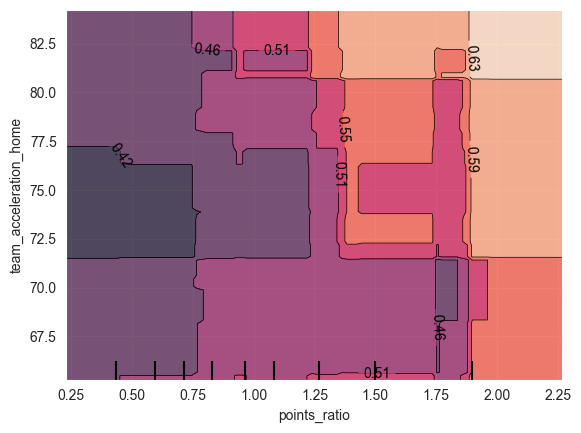

In [6]:
PartialDependenceDisplay.from_estimator(model,
                                        X=X,
                                        kind='average',
                                        features=[('points_ratio',
                                                  'team_acceleration_home')])